# BIT611 — Laboratory Activity 2 (10%)
## Titanic: Supervised + Unsupervised Algorithms (Extension of Lab 1)

**Scenario:** Using the Titanic dataset already prepared for ML in Lab 1, run supervised and unsupervised algorithms and interpret the results using simple performance measures.

### What you will do
- **Completed preprocessing included** (same rules as Lab 1)
- **Part A:** Logistic Regression (+ error-rate rule)
- **Part B:** SVM
- **Part C:** k-Means
- **Part D:** Hierarchical clustering
- **Part E:** Final comparison (120–180 words)

**Dataset URL (public):** `https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv`


In [36]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt


## Preprocessing (Completed — same as Lab 1)
**Rules:** fill `age` (median), fill `embarked` (mode), drop `deck`, one-hot encode `sex` + `embarked`, scale `age` + `fare`, 80/20 split `random_state=42`.


In [37]:
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'
df = pd.read_csv(url)

df2 = df.copy()

df2['age'] = df2['age'].fillna(df2['age'].median())
df2['embarked'] = df2['embarked'].fillna(df2['embarked'].mode(dropna=True)[0])

#Drops Columns That Aren't Used To Ensure No Error Encounted On Part A
df2 = df2.drop(columns=['class', 'who', 'alive', 'embark_town', 'adult_male', 'alone', 'deck'])

df3 = pd.get_dummies(df2, columns=['sex', 'embarked'], drop_first=False)

scaler = StandardScaler()
df4 = df3.copy()
df4[['age', 'fare']] = scaler.fit_transform(df4[['age', 'fare']])

y = df4['survived']
X = df4.drop(columns=['survived'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('✅ Preprocessing complete')
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)


✅ Preprocessing complete
X_train: (712, 10)
X_test : (179, 10)
y_train: (712,)
y_test : (179,)


## Helper functions


In [38]:
def classification_report_basic(y_true, y_pred, title: str):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    err = 1 - acc
    print(title)
    print('Accuracy   :', round(acc, 4))
    print('Precision  :', round(prec, 4))
    print('Recall     :', round(rec, 4))
    print('Error rate :', round(err, 4))
    return acc, prec, rec, err

def show_confusion(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title(title)
    plt.show()


## Part A — Supervised model 1: Logistic Regression
**Model settings:** `LogisticRegression(max_iter=300, random_state=42)`

**Performance rule:** If error rate > 0.30, rerun with `max_iter=600`.


Logistic Regression (max_iter=300)
Accuracy   : 0.8101
Precision  : 0.7857
Recall     : 0.7432
Error rate : 0.1899


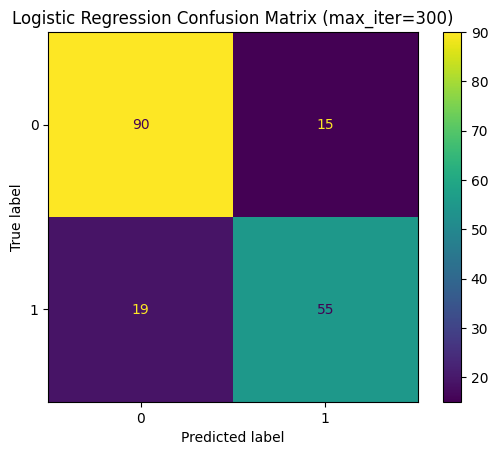

In [39]:
lr = LogisticRegression(max_iter=300, random_state=42)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

lr_acc, lr_prec, lr_rec, lr_err = classification_report_basic(y_test, pred_lr, 'Logistic Regression (max_iter=300)')
show_confusion(y_test, pred_lr, 'Logistic Regression Confusion Matrix (max_iter=300)')

if lr_err > 0.30:
    print('\n⚠️ Error rate > 0.30 → rerunning with max_iter=600...')
    lr2 = LogisticRegression(max_iter=600, random_state=42)
    lr2.fit(X_train, y_train)
    pred_lr2 = lr2.predict(X_test)
    lr_acc, lr_prec, lr_rec, lr_err = classification_report_basic(y_test, pred_lr2, 'Logistic Regression (max_iter=600)')
    show_confusion(y_test, pred_lr2, 'Logistic Regression Confusion Matrix (max_iter=600)')


## Part B — Supervised model 2: SVM
**Model settings:** `SVC(kernel='rbf', C=1, gamma='scale')`


SVM (RBF, C=1)
Accuracy   : 0.8156
Precision  : 0.806
Recall     : 0.7297
Error rate : 0.1844


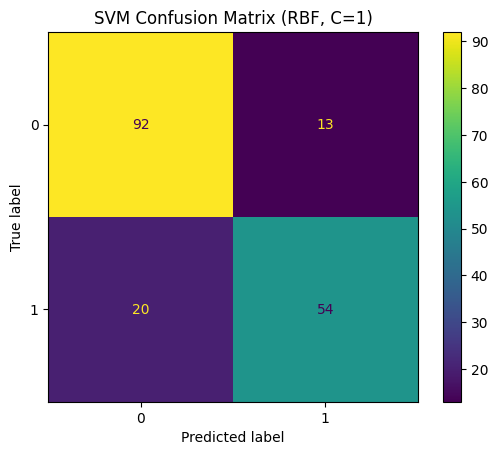

In [40]:
svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

svm_acc, svm_prec, svm_rec, svm_err = classification_report_basic(y_test, pred_svm, 'SVM (RBF, C=1)')
show_confusion(y_test, pred_svm, 'SVM Confusion Matrix (RBF, C=1)')


## Part C — Unsupervised model 1: k-Means
**Model settings:** `KMeans(n_clusters=2, random_state=42, n_init=10)`

**Outputs required:** first 10 labels + cluster counts.


In [41]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X)

print('First 10 cluster labels (k-Means):', labels_km[:10])
print('\nCluster counts (k-Means):')
print(pd.Series(labels_km).value_counts().sort_index())


First 10 cluster labels (k-Means): [0 1 0 1 0 0 1 0 0 0]

Cluster counts (k-Means):
0    635
1    256
Name: count, dtype: int64


## Part D — Unsupervised model 2: Hierarchical clustering
**Model settings:** `AgglomerativeClustering(n_clusters=2, linkage='ward')`

**Outputs required:** first 10 labels + cluster counts.


In [42]:
hc = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_hc = hc.fit_predict(X)

print('First 10 cluster labels (Hierarchical):', labels_hc[:10])
print('\nCluster counts (Hierarchical):')
print(pd.Series(labels_hc).value_counts().sort_index())


First 10 cluster labels (Hierarchical): [0 0 0 0 0 0 0 1 0 0]

Cluster counts (Hierarchical):
0    854
1     37
Name: count, dtype: int64


## Part E — Final comparison (120–180 words)
- Which supervised model performed better and why (use your metrics/confusion matrices).
- Do the unsupervised results look “balanced” or “uneven” (based on cluster counts), and what might that suggest?

Use the summary below if helpful.


In [43]:
print('--- Supervised summary ---')
print('Logistic Regression:', {'accuracy': round(lr_acc,4), 'precision': round(lr_prec,4), 'recall': round(lr_rec,4), 'error_rate': round(lr_err,4)})
print('SVM               :', {'accuracy': round(svm_acc,4), 'precision': round(svm_prec,4), 'recall': round(svm_rec,4), 'error_rate': round(svm_err,4)})

print('\n--- Unsupervised summary (counts) ---')
print('k-Means counts:')
print(pd.Series(labels_km).value_counts().sort_index())
print('\nHierarchical counts:')
print(pd.Series(labels_hc).value_counts().sort_index())


--- Supervised summary ---
Logistic Regression: {'accuracy': 0.8101, 'precision': 0.7857, 'recall': 0.7432, 'error_rate': 0.1899}
SVM               : {'accuracy': 0.8156, 'precision': 0.806, 'recall': 0.7297, 'error_rate': 0.1844}

--- Unsupervised summary (counts) ---
k-Means counts:
0    635
1    256
Name: count, dtype: int64

Hierarchical counts:
0    854
1     37
Name: count, dtype: int64


**Your 120–180 word response:**

When comparing the two supervised models, the SVM with an RBF kernel ended up performing slightly better than Logistic Regression. The SVM model got an accuracy of 0.8156 and an error rate of 0.1844, while Logistic Regression has an accuracy of 0.8101 and an error rate of 0.1899. The SVM model also had higher precision (0.806 Vs. 0.7857), although Logistic Regression did slightly better on recall (0.7432 Vs. 0.7297). Overall, both models performed similarly, but the SVM model seems to generalise slightly better for this specific dataset.

Unlike the supervised models, the unsupervised models produced very uneven clusters. k-Means split the data into clusters of 635 and 256, whcih indicates a clear imbalance. Hierarchical clustering was even more unbalanced, with one cluster having 854 passengers and the other only 37. This suggests that the natural structure of the dataset is'nt evenly divided, and these clusters don't align with the more balanced patterns seen in the supervised models. Overall, the supervised models provided more meaningful predictions, while the unsupervised models only highlighted broad groupings in the data.


## References / acknowledgements
- Dataset: Titanic (seaborn-data) — `https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv`
- Any other sources you used and any AI tools used (what you used them for).
